In [7]:
import pickle
import pandas as pd
from pandas import Series
from tqdm import tqdm
import seaborn as sns
import numpy as np

import matplotlib
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
from matplotlib import rc

from sklearn.preprocessing import normalize
from sklearn.linear_model import LinearRegression

In [8]:
import matplotlib.pyplot as plt 
plt.rcParams.update({
    "font.family" : 'Arial',   # specify font family here
    "font.size" : 12,
    "font.weight" : "normal"})          # specify font size here

In [9]:
base_path= '/home/jinny/projects/Art-history/Art-history/datas/'

df = pd.read_csv(base_path+'words/vocas_counting_new.csv')
df_idx = pd.read_csv(base_path+'words/vocas_new.csv')

df = df.set_index("voca_index")
df_idx = df_idx.set_index("voca_index")

In [10]:
df_norm = pd.DataFrame(normalize(df, norm='l1', axis=0), columns=[int(x) for x in df.columns])
df_norm.index = df.index

idx2word = dict(zip(df_idx['index'], df_idx['word']))
wordidx2cnt = df.sum(axis=1)
wordidx2cnt = wordidx2cnt.sort_values(ascending=0)
word2idx = {v:k for k,v in idx2word.items()}

In [11]:
words_a = ['jesus','angel','saint']
words_b = ['man','woman','people']
words_c = ['portrait','abstract']
words_d = ['mountain','river','trees']
words_e = ['train','ship']
words_f = ['blue','red','green']

words_zip = [words_a, words_b, words_c, words_d, words_e, words_f]

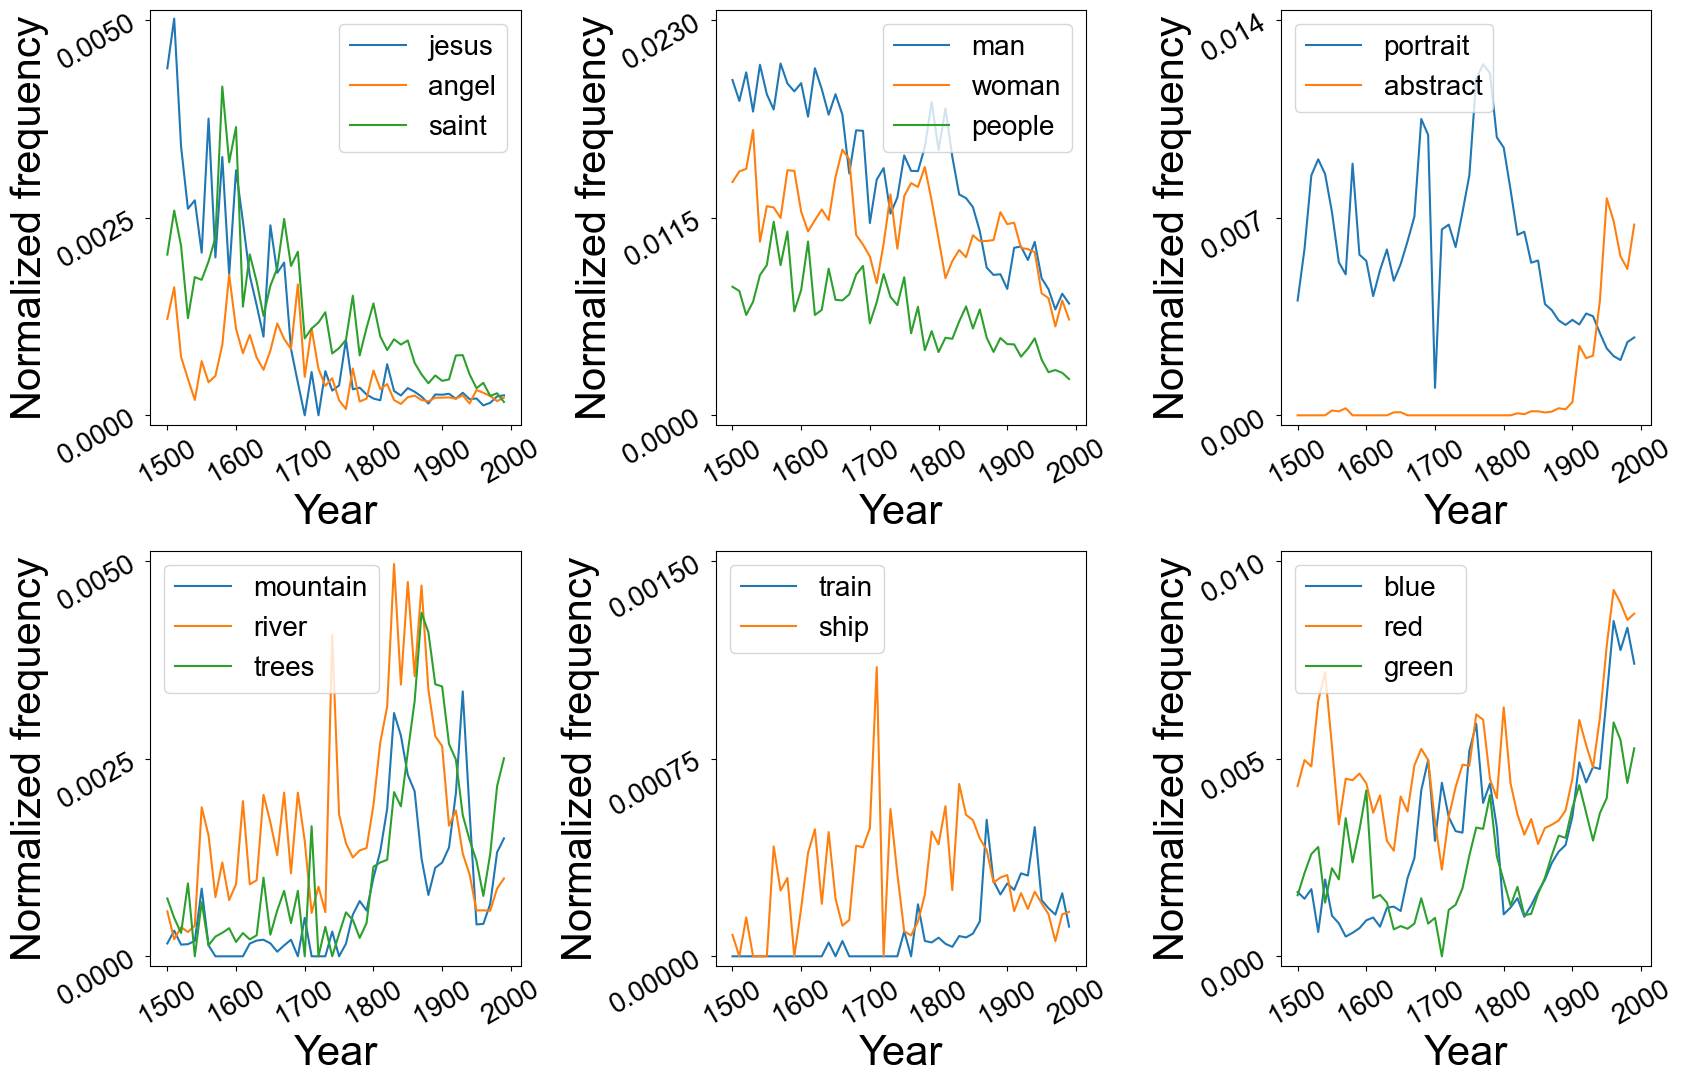

In [12]:
import numpy as np
import matplotlib.ticker as ticker

fig, ax = plt.subplots(2, 3, figsize=(17, 11))
ax = ax.reshape(-1)

#lims = [[0.00,0.004,0.008],[0.00,0.005,0.01],[0.00,0.08,0.16],[0.00,0.0005,0.001],[0.00,0.001,0.002],[0.00,0.001,0.002]]
lims = [[0.00,0.05,0.10],[0.00,0.23,0.46],[0.00,0.14,0.28],[0.00,0.05,0.10],[0.00,0.015,0.03],[0.00,0.10,0.20]]
lims = [np.array(i)*0.05 for i in lims]

for idx, words in enumerate(words_zip):
    for i, word in enumerate(words):
        ax[idx].plot(df_norm[df_norm.columns.difference(['slope', 'word'])].loc[word2idx[word]], label=f'{word}')
    if idx in [0,1] :
        ax[idx].legend(bbox_to_anchor=(1, 1), fontsize=20, loc="upper right")
    else :
        ax[idx].legend(bbox_to_anchor=(0, 1), fontsize=20, loc="upper left")
    ax[idx].set_xlabel('Year', fontsize=30)
    ax[idx].set_ylabel('Normalized frequency', fontsize=30)

    # Set 5 y-ticks between the min and max values
    ax[idx].set_yticks(lims[idx])  # Set 5 evenly spaced ticks


    # Format y-ticks to 2 decimal places
    #ax[idx].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.4f'))
    r = lims[idx][2]-lims[idx][0]
    ax[idx].set_ylim(lims[idx][0]-r*0.025,lims[idx][2]+r*0.025)

    # Ensure all x-ticks are shown
    ax[idx].set_xticks([1500+i*100 for i in range(6)])  # Set all x-ticks

    # Set tick label sizes
    ax[idx].tick_params(axis='x', labelsize=20, rotation=30)
    ax[idx].tick_params(axis='y', labelsize=20, rotation=30)


plt.tight_layout()  # Ensure that subplots do not overlap
plt.savefig('/home/jinny/projects/Art-history/Art-history/graph/figure03.svg',bbox_inches='tight',transparent = True,dpi=600)
plt.show()
